# IPL 2022 Data Analysis Capstone Project

## Project Overview
The **Indian Premier League (IPL)** is a premier professional T20 cricket league in India featuring city-based franchises. This capstone project analyzes match-level dataset from the 2022 season to unpack team performance dynamics, player impact, and tactical match outcomes.

---

## Dataset Schema & Variables

| Variable | Data Type | Description |
| :--- | :---: | :--- |
| **`date`** | *String* | Date of the match |
| **`venue`** | *String* | Stadium/Ground where the match was played |
| **`stage`** | *String* | Tournament phase (e.g., Group Stage, Playoff, Final) |
| **`team1`** | *String* | First participating team |
| **`team2`** | *String* | Second participating team |
| **`toss_winner`** | *String* | Team that won the toss |
| **`toss_decision`** | *String* | Decision chosen after toss (`field` / `bat`) |
| **`first_ings_score`** | *Integer* | Total runs scored in 1st innings |
| **`second_ings_score`** | *Integer* | Total runs scored in 2nd innings |
| **`match_winner`** | *String* | Team that won the match |
| **`won_by`** | *String* | Victory mode (`Runs` / `Wickets`) |
| **`margin`** | *Integer* | Victory margin value |
| **`player_of_the_match`** | *String* | Man of the match awardee |
| **`top_scorer`** | *String* | Highest run-getter in the match |
| **`highscore`** | *Integer* | Highest individual score in the match |
| **`best_bowling`** | *String* | Bowler with the best figures |
| **`best_bowling_figure`** | *String* | Best bowling stats recorded |

### **Loading the libraries and dataset**

In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
df = pd.read_csv( 'IPL.csv')

df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## **Basic info**

#### information about whole dataset

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

### Info About the Dataset Shape

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

## Now from here we start the main analysis

### who won the most matches in this season

In [148]:
top_team = df["match_winner"].value_counts().idxmax()
total_wins = df["match_winner"].value_counts().max()

print(f"{top_team} won the most matches with {total_wins} wins.")

Gujarat won the most matches with 12 wins.


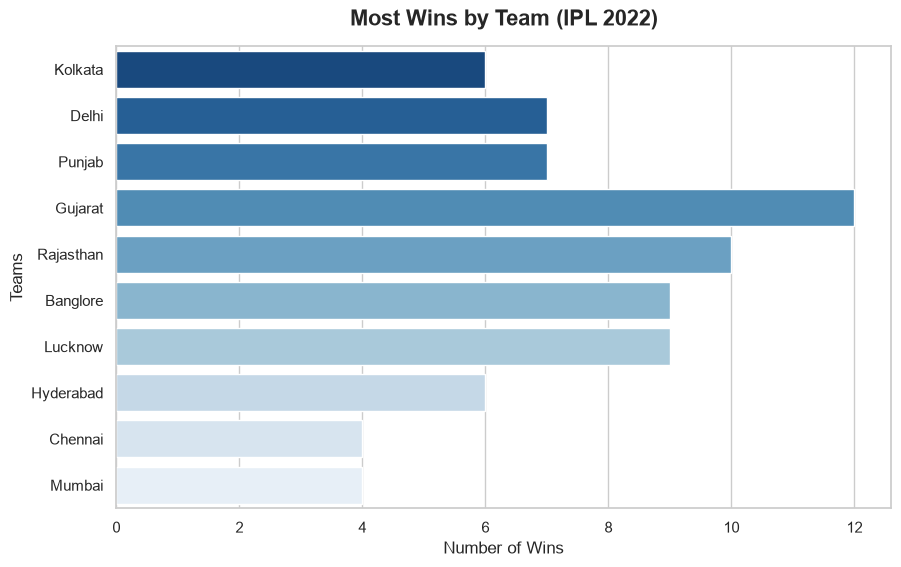

Gujarat won the most matches with 12 wins.


In [149]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.countplot(data=df, y = "match_winner" ,palette="Blues_r")

plt.title("Most Wins by Team (IPL 2022)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Number of Wins", fontsize=12)
plt.ylabel("Teams", fontsize=12)
plt.show()

print(f"{top_team} won the most matches with {total_wins} wins.")

> Gujarat Titans led the season with 12 wins, followed closely by a tight chasing pack — showing the 2022 season had no single dominant team beyond the top spot.

### Toss Trends

In [150]:
df["toss_decision"].value_counts()

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='toss_decision'>

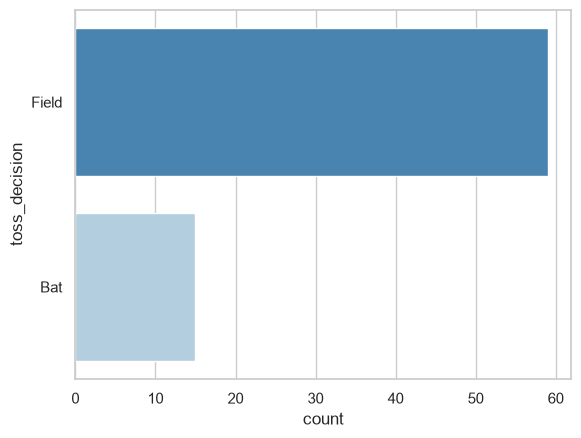

In [151]:
sns.countplot(y="toss_decision", data=df, palette="Blues_r")

> Captains chose to field first in 59 of 74 matches (~80%), showing a strong league-wide preference for chasing under 2022 conditions.

### Toss winner vs Match winner

In [152]:
toss_and_match_wins = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()
total_matches = df["match_id"].count()
toss_lost_match_wins = total_matches - toss_and_match_wins

summary_df = pd.DataFrame({
    "Outcome": ["Won Toss & Match", "Lost Toss & Won Match"],
    "Count": [toss_and_match_wins, toss_lost_match_wins]
})
summary_df["Percentage"] = ((summary_df["Count"] / total_matches) * 100).round(1)
summary_df

,Outcome,Count,Percentage
0,Won Toss & Match,36,48.6
1,Lost Toss & Won Match,38,51.4


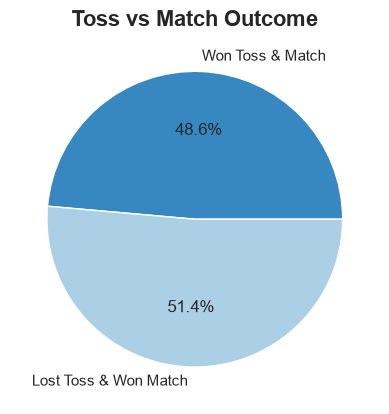

In [153]:
values = summary_df["Percentage"]
labels = summary_df["Outcome"]

color = sns.color_palette("Blues_r", 2)

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    colors=color 
)

plt.title("Toss vs Match Outcome", fontsize=16 , fontweight="bold")
plt.show()

> Winning the toss did not translate into winning the match — toss winners went on to win only 48.6% of the time, essentially a coin flip. This suggests toss advantage was minimal in IPL 2022, likely because most captains chose the same strategy (fielding) regardless of conditions.

### How do teams win? (Runs vs Wickets)

In [154]:
win_by_runs = df[df["won_by"] == "Wickets"]["won_by"].count()
win_by_wickets = df["won_by"].count() - win_by_runs

df_runVSwkt = pd.DataFrame({
    "Outcome": ["Matches won by Runs", "Matches won by wickets"],
    "Count": [win_by_runs, win_by_wickets]
})

df_runVSwkt["Percentage %"] = (win_by_runs*100/df["won_by"].count(), win_by_wickets*100/df["won_by"].count())
df_runVSwkt

,Outcome,Count,Percentage %
0,Matches won by Runs,37,50.0
1,Matches won by wickets,37,50.0


Text(0.5, 1.0, 'Won by runs vs wickets')

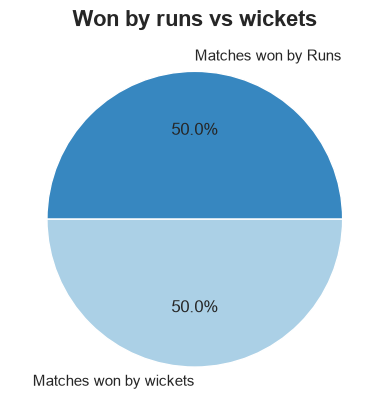

In [155]:
color = sns.color_palette("Blues_r", 2)

plt.pie(
    df_runVSwkt["Percentage %"],
    labels=df_runVSwkt["Outcome"],
    autopct="%1.1f%%",
    colors=color 
)

plt.title("Won by runs vs wickets", fontweight="bold", fontsize=16)

> Matches were split exactly 50/50 between wins by runs and wins by wickets, indicating no systemic advantage to batting first or chasing across the season as a whole.

### Most "Player of the match" winner

In [ ]:
most_potm = df["player_of_the_match"].value_counts().idxmax()
total_potm = df["player_of_the_match"].value_counts().max()
print(f"{most_potm} won the most POTM, {total_potm} times")

#### top 5 players with most POTM title in this season IPL 2022

In [157]:
top5_potm = df["player_of_the_match"].value_counts().head(5).reset_index().rename(columns={"player_of_the_match": "Player","count": "POTM Awards"})
top5_potm

,Player,POTM Awards
0,Kuldeep Yadav,4
1,Jos Buttler,3
2,Umesh Yadav,2
3,Wanindu Hasaranga,2
4,Avesh Khan,2


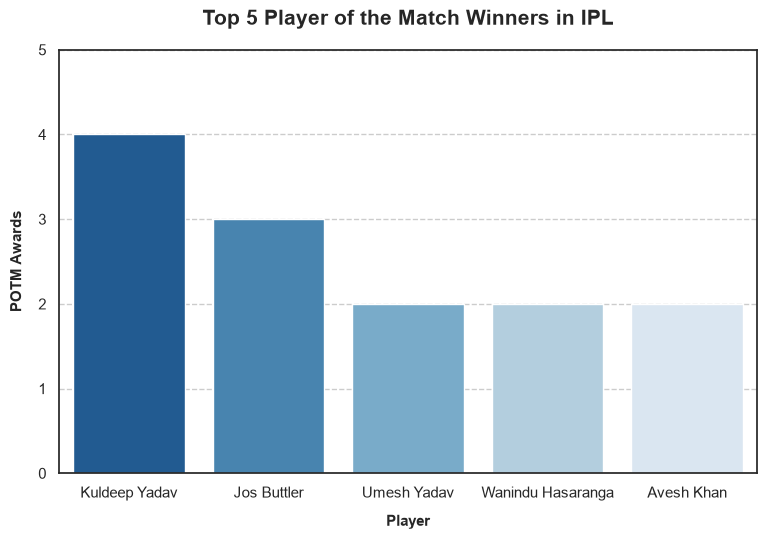

In [158]:
sns.set_theme(style="white")
plt.figure(figsize=(9, 5.5))
sns.barplot(
    data=top5_potm,
    x="Player",
    y="POTM Awards",
    palette="Blues_r",
)

plt.title(
    "Top 5 Player of the Match Winners in IPL",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
plt.xlabel("Player", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("POTM Awards", fontsize=11, fontweight="bold", labelpad=10)
plt.ylim(0,5) 
plt.grid(axis="y", linestyle="--")

plt.show()

> Kuldeep Yadav was the standout individual performer of the season, claiming 4 Player of the Match awards — one more than any other player, and a strong signal of consistent match-winning impact.

#### Top 5 Highest Individual Scores in IPL 2022


In [159]:
high_score = df.nlargest(5, "highscore")[["top_scorer", "highscore"]].rename(columns={"top_scorer":"Player","highscore":"Score"})
high_score

,Player,Score
65,Quinton de Kock,140
33,Jos Buttler,116
71,Rajat Patidar,112
72,Jos Buttler,106
25,KL Rahul,103


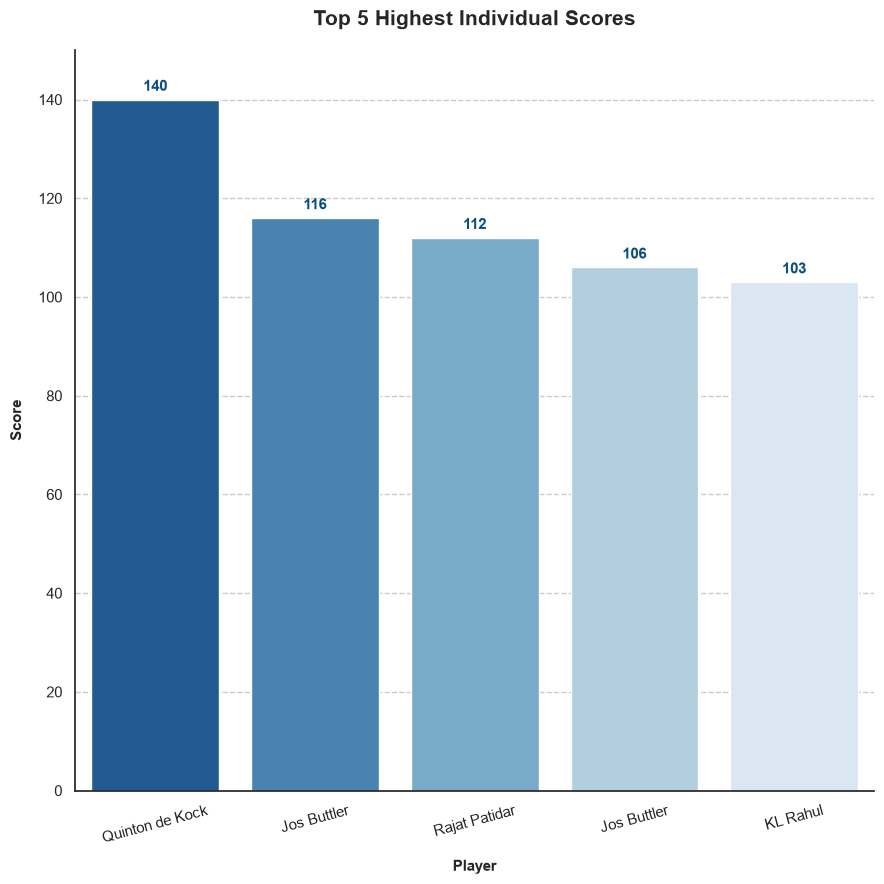

In [160]:
high_score["Label"] = high_score["Player"] + high_score.groupby("Player").cumcount().astype(str).str.replace("0", "")
high_score["Label"] = high_score["Label"].str.strip()

sns.set_theme(style="white")
plt.figure(figsize=(9,9))

ax = sns.barplot(
    data=high_score,
    x="Label",
    y="Score",
    hue="Label",
    palette="Blues_r",
    legend=False,
    order=high_score["Label"],
)

for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=11, fontweight="bold", color="#0b4e82")

sns.despine()
plt.title("Top 5 Highest Individual Scores", fontsize=15, fontweight="bold", pad=18)
ax.set_xticklabels(high_score["Player"])
plt.xlabel("Player", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Score", fontsize=11, fontweight="bold", labelpad=10)
plt.ylim(0, 150)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--")
plt.tight_layout()
plt.show()

> Quinton de Kock's 140 was the highest individual score of the season, with Jos Buttler appearing twice in the top 5 — underlining his standout batting form throughout 2022.

### Top 5 Best Bowling Figures

In [ ]:
def parse_bowling_figure(fig):
    try:
        wkts, runs = fig.split('--')
        return int(wkts), int(runs)
    except (ValueError, AttributeError):
        return None, None

df[['wickets', 'runs']] = df['best_bowling_figure'].apply(
    lambda x: pd.Series(parse_bowling_figure(x))
)

best = df.sort_values(
    ['wickets', 'runs'],
    ascending=[False, True]
)

best_fig = pd.DataFrame({
    "Rank": range(1, 6),
    "Bowler": best["best_bowling"].head(5).values,
    "Figure": best["best_bowling_figure"].head(5).values
})

best_fig

> Jasprit Bumrah's 5/10 was the best bowling figure of the season, a dominant spell by both wickets taken and economy.

### Distribution of Matches Across IPL Stadiums

In [162]:
df["Stadium"] = df["venue"].apply(lambda x: x.split(',')[0])

stadium_counts = (
    df["Stadium"]
    .value_counts()
    .reset_index()
    .rename(columns={"count": "No. of matches hosted"})
)

stadium_counts

,Stadium,No. of matches hosted
0,Wankhede Stadium,21
1,Dr DY Patil Sports Academy,20
2,Brabourne Stadium,16
3,Maharashtra Cricket Association Stadium,13
4,Eden Gardens,2
5,Narendra Modi Stadium,2


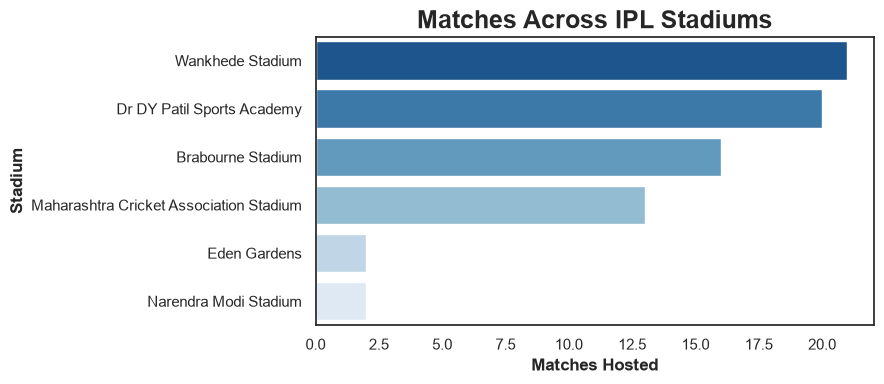

In [181]:
sns.set_theme(style="white")
plt.figure(figsize=(9, 4))

sns.barplot(
    data=stadium_counts,
    x="matches_hosted",
    y="stadium",
    palette="Blues_r",
)

plt.title("Matches Across IPL Stadiums",fontweight="bold", fontsize=18)
plt.xlabel("Matches Hosted",fontweight="bold")
plt.ylabel("Stadium", fontweight="bold")

plt.tight_layout()
plt.show()

> Wankhede Stadium hosted nearly a third of all matches (21 of 74), reflecting the season's heavy use of Mumbai-based venues over others like Eden Gardens and Narendra Modi Stadium, which hosted only 2 each.

## 🔑 Key Findings

- **Gujarat Titans** won the most matches this season (12 wins).
- **Winning the toss had almost no predictive value** — toss winners won only 48.6% of matches.
- **Fielding first was the dominant choice**, picked in ~80% of tosses.
- Matches were **evenly split between wins by runs and wickets** (50/50).
- **Kuldeep Yadav** led all players with 4 Player of the Match awards.
- **Quinton de Kock** (140) and **Jasprit Bumrah** (5/10) posted the season's best individual batting and bowling performances.
- **Wankhede Stadium** was the season's primary venue, hosting 21 of 74 matches.
